In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------------------
# Utilidades básicas
# -------------------------------------------
def cargar_pgm(path):
    img = Image.open(path).convert("L")
    return np.array(img, dtype=float)

def mostrar(img, titulo=""):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap="gray")
    plt.title(titulo)
    plt.axis("off")
    plt.show()

# -------------------------------------------
# Construcción de malla (distancias)
# -------------------------------------------
def crear_distancias(M, N):
    u = np.arange(0, M)
    v = np.arange(0, N)
    u, v = np.meshgrid(u, v, indexing="ij")
    D = np.sqrt((u - M/2)**2 + (v - N/2)**2)
    return D

# -------------------------------------------
# 1. Ideal Low-Pass (LPF) basado en ciclos
# -------------------------------------------
def ideal_lowpass(D0, img):
    M, N = img.shape
    D = crear_distancias(M, N)
    H = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            H[i, j] = 1 if D[i, j] <= D0 else 0

    return H

# -------------------------------------------
# 2. Butterworth Low-Pass (LPF)
# -------------------------------------------
def butterworth_lowpass(D0, n, img):
    M, N = img.shape
    D = crear_distancias(M, N)
    H = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            H[i, j] = 1 / (1 + (D[i,j] / D0)**(2*n))

    return H

# -------------------------------------------
# 3. Gaussian Low-Pass (LPF)
# -------------------------------------------
def gaussian_lowpass(D0, img):
    M, N = img.shape
    D = crear_distancias(M, N)
    H = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            H[i,j] = np.exp(-(D[i,j]**2) / (2 * (D0**2)))

    return H

# -------------------------------------------
# 4. Ideal High-Pass (HPF)
# -------------------------------------------
def ideal_highpass(D0, img):
    M, N = img.shape
    D = crear_distancias(M, N)
    H = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            H[i, j] = 0 if D[i, j] <= D0 else 1

    return H

# -------------------------------------------
# 5. Butterworth High-Pass (HPF)
# -------------------------------------------
def butterworth_highpass(D0, n, img):
    M, N = img.shape
    D = crear_distancias(M, N)
    H = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            if D[i,j] == 0:
                H[i,j] = 0
            else:
                H[i,j] = 1 / (1 + (D0 / D[i,j])**(2*n))

    return H

# -------------------------------------------
# 6. Gaussian High-Pass (HPF)
# -------------------------------------------
def gaussian_highpass(D0, img):
    M, N = img.shape
    D = crear_distancias(M, N)
    H = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            H[i,j] = 1 - np.exp(-(D[i,j]**2) / (2*(D0**2)))

    return H

# -------------------------------------------
# Aplicar filtro (común a todos)
# -------------------------------------------
def aplicar_filtro(img, H):
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)
    G = F_shift * H
    g = np.fft.ifft2(np.fft.ifftshift(G))
    return np.abs(g)


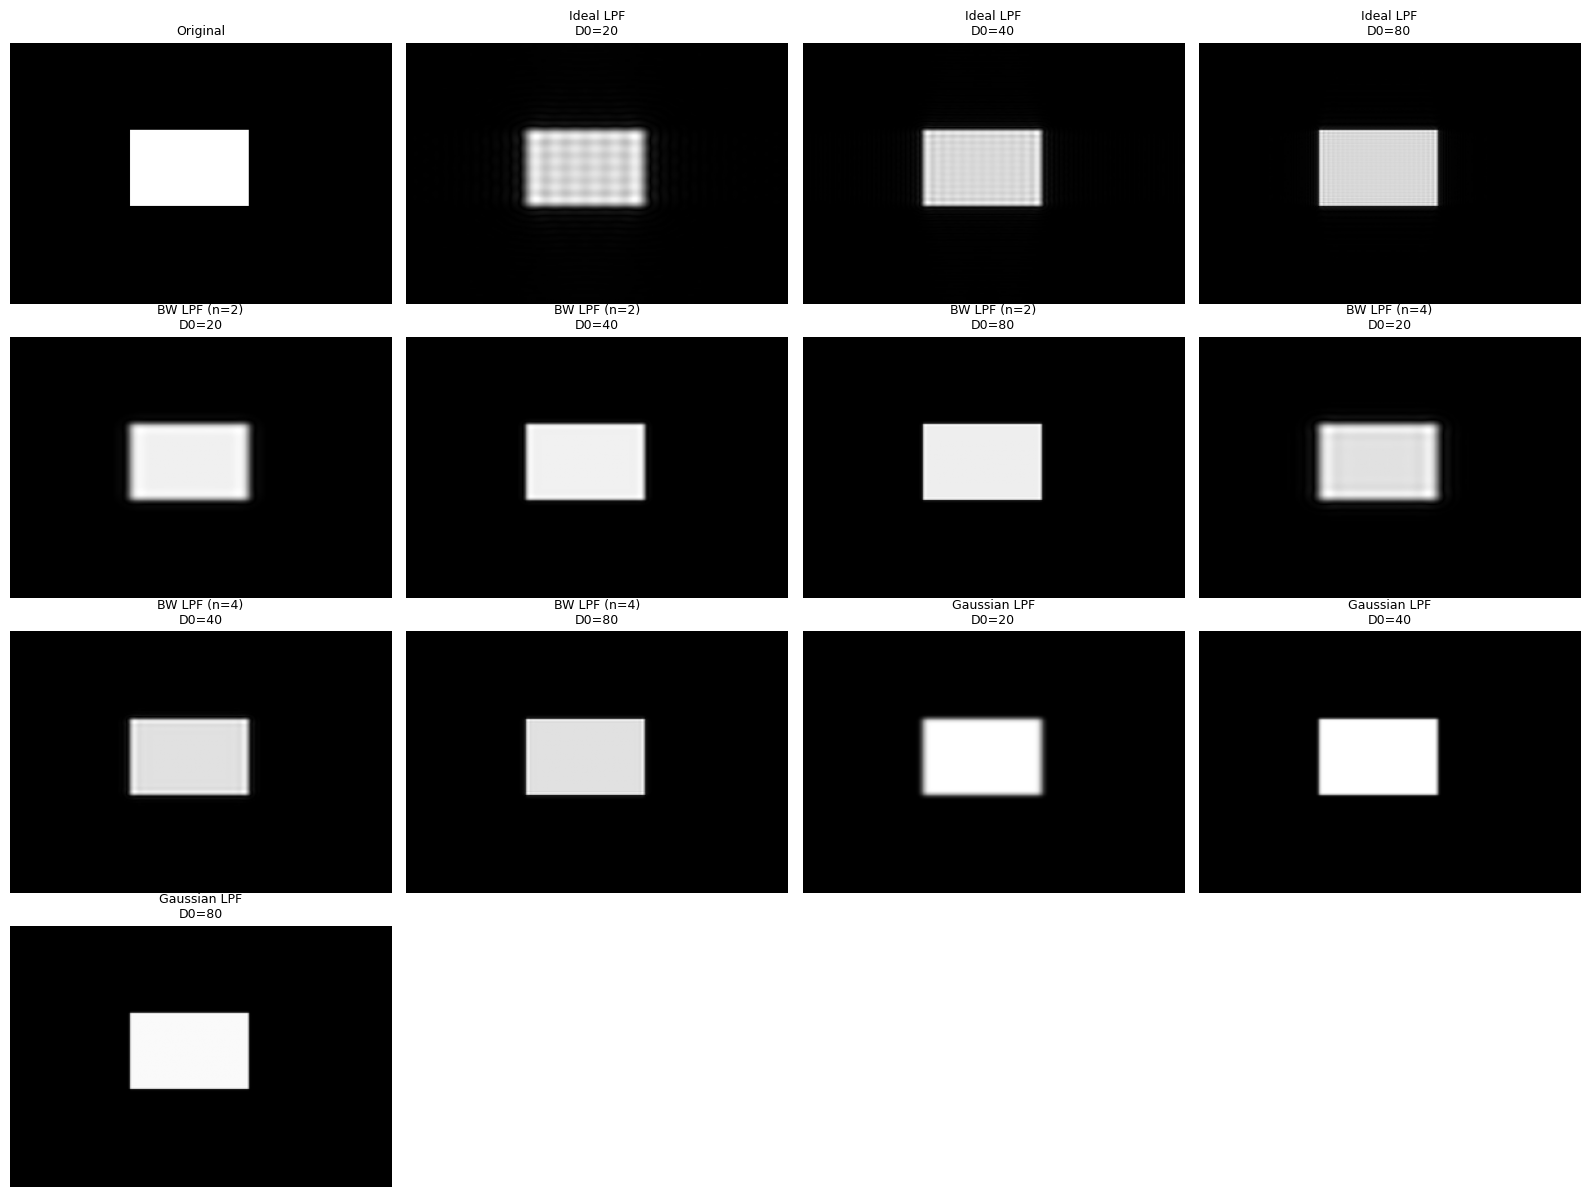

In [ ]:
img = cargar_pgm("images/RectOne.pgm")

# ----------------------------------------------------------
# PREPARAR TODAS LAS IMÁGENES
# ----------------------------------------------------------
resultados = []
titulos = []

# Imagen original
resultados.append(img)
titulos.append("Original")

# Ideal LPF (20,40,80)
for D0 in [20, 40, 80]:
    H = ideal_lowpass(D0, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"Ideal LPF\nD0={D0}")

# Butterworth LPF orden 2
for D0 in [20, 40, 80]:
    H = butterworth_lowpass(D0, 2, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"BW LPF (n=2)\nD0={D0}")

# Butterworth LPF orden 4
for D0 in [20, 40, 80]:
    H = butterworth_lowpass(D0, 4, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"BW LPF (n=4)\nD0={D0}")

# Gaussian LPF (20,40,80)
for D0 in [20, 40, 80]:
    H = gaussian_lowpass(D0, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"Gaussian LPF\nD0={D0}")


# ----------------------------------------------------------
# GENERAR GRID
# ----------------------------------------------------------
num_imgs = len(resultados)     # 1 + 3 + 3 + 3 + 3 = 13
cols = 4
rows = int(np.ceil(num_imgs / cols))

plt.figure(figsize=(16, 12))

for i, (img_res, title) in enumerate(zip(resultados, titulos)):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img_res, cmap="gray")
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

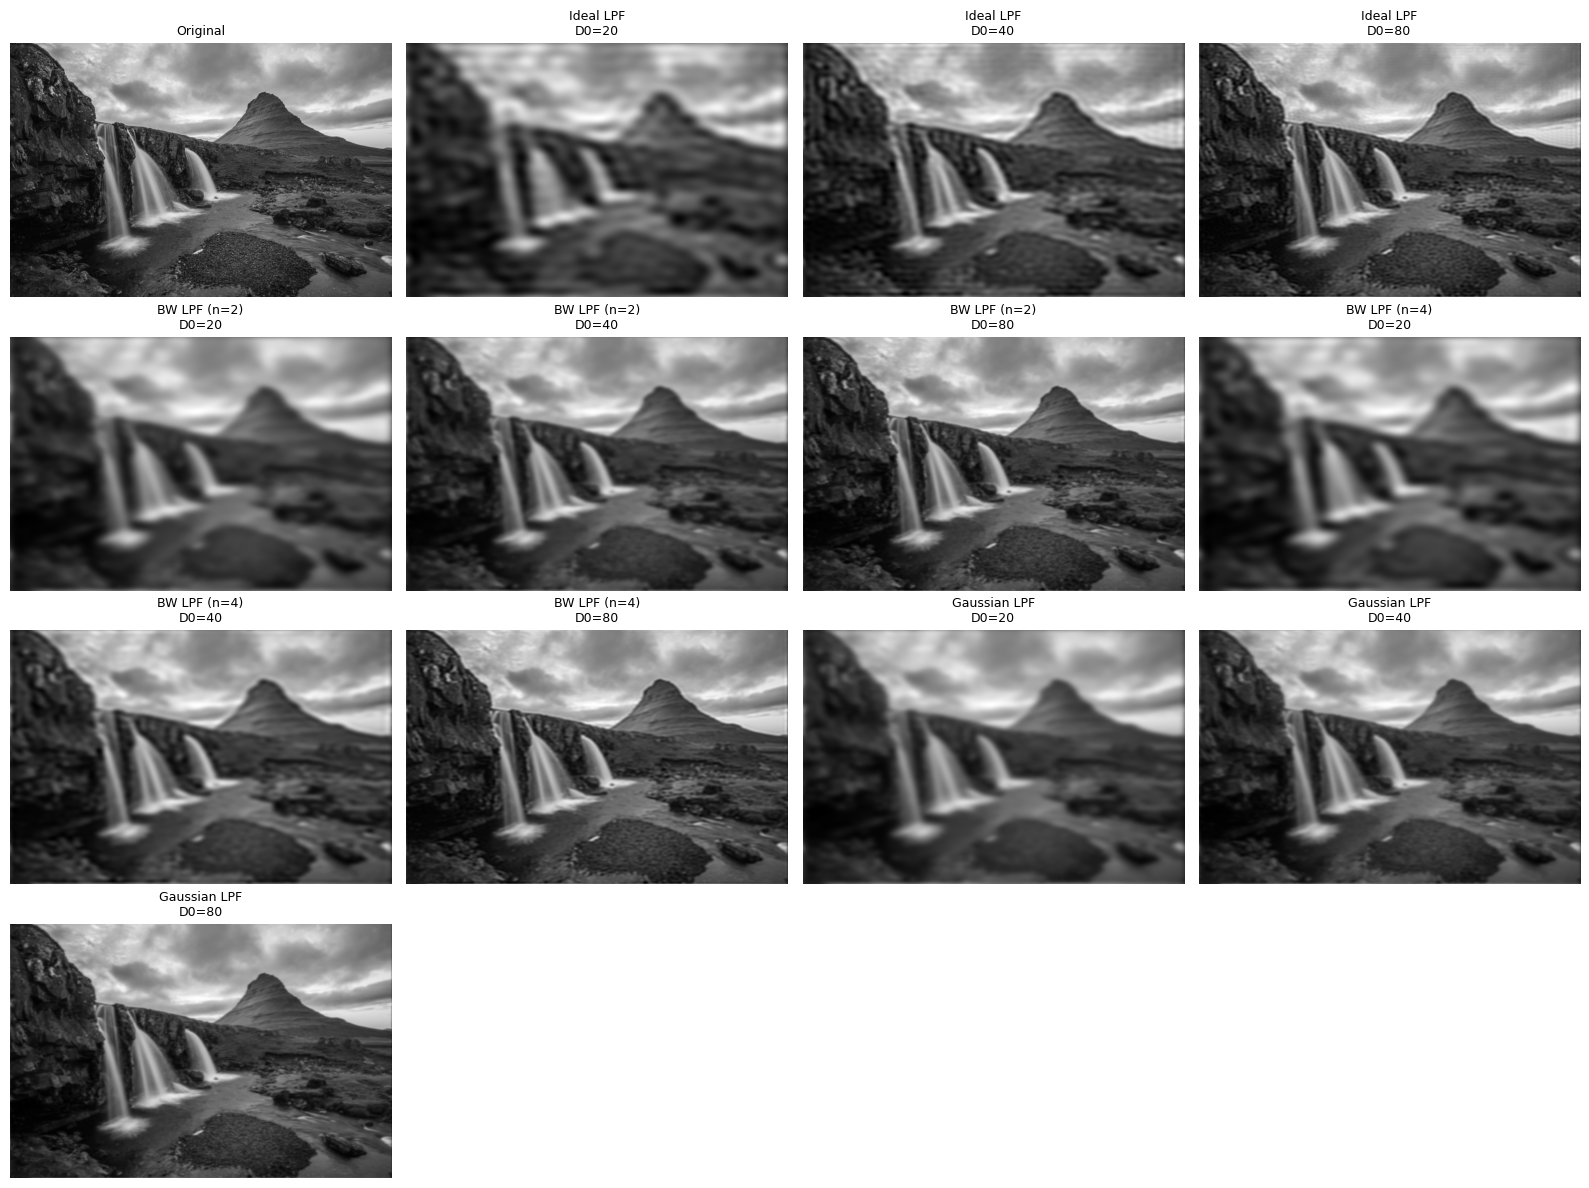

In [ ]:
img = cargar_pgm("images/kirkjufell.jpg")

# ----------------------------------------------------------
# PREPARAR TODAS LAS IMÁGENES
# ----------------------------------------------------------
resultados = []
titulos = []

# Imagen original
resultados.append(img)
titulos.append("Original")

# Ideal LPF (20,40,80)
for D0 in [20, 40, 80]:
    H = ideal_lowpass(D0, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"Ideal LPF\nD0={D0}")

# Butterworth LPF orden 2
for D0 in [20, 40, 80]:
    H = butterworth_lowpass(D0, 2, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"BW LPF (n=2)\nD0={D0}")

# Butterworth LPF orden 4
for D0 in [20, 40, 80]:
    H = butterworth_lowpass(D0, 4, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"BW LPF (n=4)\nD0={D0}")

# Gaussian LPF (20,40,80)
for D0 in [20, 40, 80]:
    H = gaussian_lowpass(D0, img)
    filtrada = aplicar_filtro(img, H)
    resultados.append(filtrada)
    titulos.append(f"Gaussian LPF\nD0={D0}")


# ----------------------------------------------------------
# GENERAR GRID
# ----------------------------------------------------------
num_imgs = len(resultados)     # 1 + 3 + 3 + 3 + 3 = 13
cols = 4 
rows = int(np.ceil(num_imgs / cols))

plt.figure(figsize=(16, 12))

for i, (img_res, title) in enumerate(zip(resultados, titulos)):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img_res, cmap="gray")
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import imageio.v2 as imageio

def cargar_imagen(path):
    return imageio.imread(path).astype(np.float32)

def crear_salida(img):
    return np.zeros_like(img)

def detectar_puntos(img, incluir_promedio=True):
    h, w = img.shape
    out = crear_salida(img)

    kernel = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.float32)

    if incluir_promedio:
        kernel = kernel / 9.0

    for i in range(1, h-1):
        for j in range(1, w-1):
            suma = 0
            for ki in range(-1, 2):
                for kj in range(-1, 2):
                    suma += img[i+ki, j+kj] * kernel[ki+1, kj+1]
            out[i, j] = abs(suma)

    return out


def detectar_lineas(img, umbral=80):
    h, w = img.shape
    out = crear_salida(img)

    K_h = np.array([[-1,-1,-1],[ 2,2,2],[-1,-1,-1]])
    K_v = np.array([[-1,2,-1],[-1,2,-1],[-1,2,-1]])
    K_d = np.array([[2,-1,-1],[-1,2,-1],[-1,-1,2]])

    kernels = [K_h, K_v, K_d]

    for i in range(1, h-1):
        for j in range(1, w-1):

            respuestas = []
            for K in kernels:
                suma = 0
                for ki in range(3):
                    for kj in range(3):
                        suma += img[i+ki-1, j+kj-1] * K[ki, kj]
                respuestas.append(abs(suma))

            val = max(respuestas)
            out[i, j] = 255 if val > umbral else 0

    return out

def prewitt(img):
    h, w = img.shape
    out = crear_salida(img)

    Gx = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
    Gy = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

    for i in range(1,h-1):
        for j in range(1,w-1):
            sx = sy = 0
            for ki in range(3):
                for kj in range(3):
                    px = img[i+ki-1, j+kj-1]
                    sx += px * Gx[ki, kj]
                    sy += px * Gy[ki, kj]
            out[i,j] = np.sqrt(sx**2 + sy**2)

    return out

def sobel(img):
    h, w = img.shape
    out = crear_salida(img)

    Gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    Gy = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

    for i in range(1,h-1):
        for j in range(1,w-1):
            sx = sy = 0
            for ki in range(3):
                for kj in range(3):
                    px = img[i+ki-1, j+kj-1]
                    sx += px * Gx[ki, kj]
                    sy += px * Gy[ki, kj]
            out[i,j] = np.sqrt(sx**2 + sy**2)

    return out

def laplaciano(img):
    h, w = img.shape
    out = crear_salida(img)

    K = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])

    for i in range(1,h-1):
        for j in range(1,w-1):
            suma = 0
            for ki in range(3):
                for kj in range(3):
                    suma += img[i+ki-1, j+kj-1] * K[ki, kj]
            out[i,j] = abs(suma)

    return out

def marr_hildreth(img, sigma=2):
    # 1. Crear kernel Gaussiano NxN
    N = int(6*sigma) + 1
    G = np.zeros((N,N), dtype=np.float32)
    c = N//2
    for i in range(N):
        for j in range(N):
            x, y = i-c, j-c
            G[i,j] = np.exp(-(x*x+y*y)/(2*sigma*sigma))
    G /= G.sum()

    # 2. Suavizar imagen
    h, w = img.shape
    suav = crear_salida(img)

    for i in range(c, h-c):
        for j in range(c, w-c):
            suma = 0
            for ki in range(N):
                for kj in range(N):
                    suma += img[i+ki-c, j+kj-c] * G[ki, kj]
            suav[i,j] = suma

    # 3. Aplicar Laplaciano
    L = laplaciano(suav)

    # 4. Zero-crossings
    out = crear_salida(img)
    for i in range(1,h-1):
        for j in range(1,w-1):
            vecinos = L[i-1:i+2, j-1:j+2]
            if vecinos.min() < 0 and vecinos.max() > 0:
                out[i,j] = 255

    return out

def canny(img, sigma=5, t1=50, t2=120):
    # 1. Gaussiano
    N = int(6*sigma)+1
    G = np.zeros((N,N), np.float32)
    c = N//2
    for i in range(N):
        for j in range(N):
            x,y = i-c, j-c
            G[i,j] = np.exp(-(x*x+y*y)/(2*sigma*sigma))
    G /= G.sum()

    h,w = img.shape
    smooth = crear_salida(img)

    for i in range(c, h-c):
        for j in range(c, w-c):
            suma = 0
            for ki in range(N):
                for kj in range(N):
                    suma += img[i+ki-c, j+kj-c] * G[ki, kj]
            smooth[i,j] = suma

    # 2. Gradientes Sobel
    Gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    Gy = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

    grad = crear_salida(img)
    ang = np.zeros_like(img)

    for i in range(1,h-1):
        for j in range(1,w-1):
            sx = sy = 0
            for ki in range(3):
                for kj in range(3):
                    px = smooth[i+ki-1, j+kj-1]
                    sx += px * Gx[ki, kj]
                    sy += px * Gy[ki, kj]
            grad[i,j] = np.sqrt(sx*sx + sy*sy)
            ang[i,j] = np.arctan2(sy, sx)

    # 3. Supresión no máxima
    nms = crear_salida(img)

    for i in range(1,h-1):
        for j in range(1,w-1):
            theta = ang[i,j]
            g = grad[i,j]

            # Cuantización de dirección
            if -0.39 < theta <= 0.39:  # 0°
                q = grad[i, j+1]
                r = grad[i, j-1]
            elif 0.39 < theta <= 1.18:  # 45°
                q = grad[i+1, j+1]
                r = grad[i-1, j-1]
            elif abs(theta) > 1.18 and abs(theta) <= 1.96:  # 90°
                q = grad[i+1, j]
                r = grad[i-1, j]
            else:  # 135°
                q = grad[i+1, j-1]
                r = grad[i-1, j+1]

            if g >= q and g >= r:
                nms[i,j] = g

    # 4. Double threshold
    strong = 255
    weak = 60

    out = np.zeros_like(nms)

    strong_i, strong_j = np.where(nms >= t2)
    weak_i, weak_j = np.where((nms >= t1) & (nms < t2))

    out[strong_i, strong_j] = strong
    out[weak_i, weak_j] = weak

    # 5. Histeresis
    for i in range(1,h-1):
        for j in range(1,w-1):
            if out[i,j] == weak:
                if strong in out[i-1:i+2, j-1:j+2]:
                    out[i,j] = strong
                else:
                    out[i,j] = 0

    return out

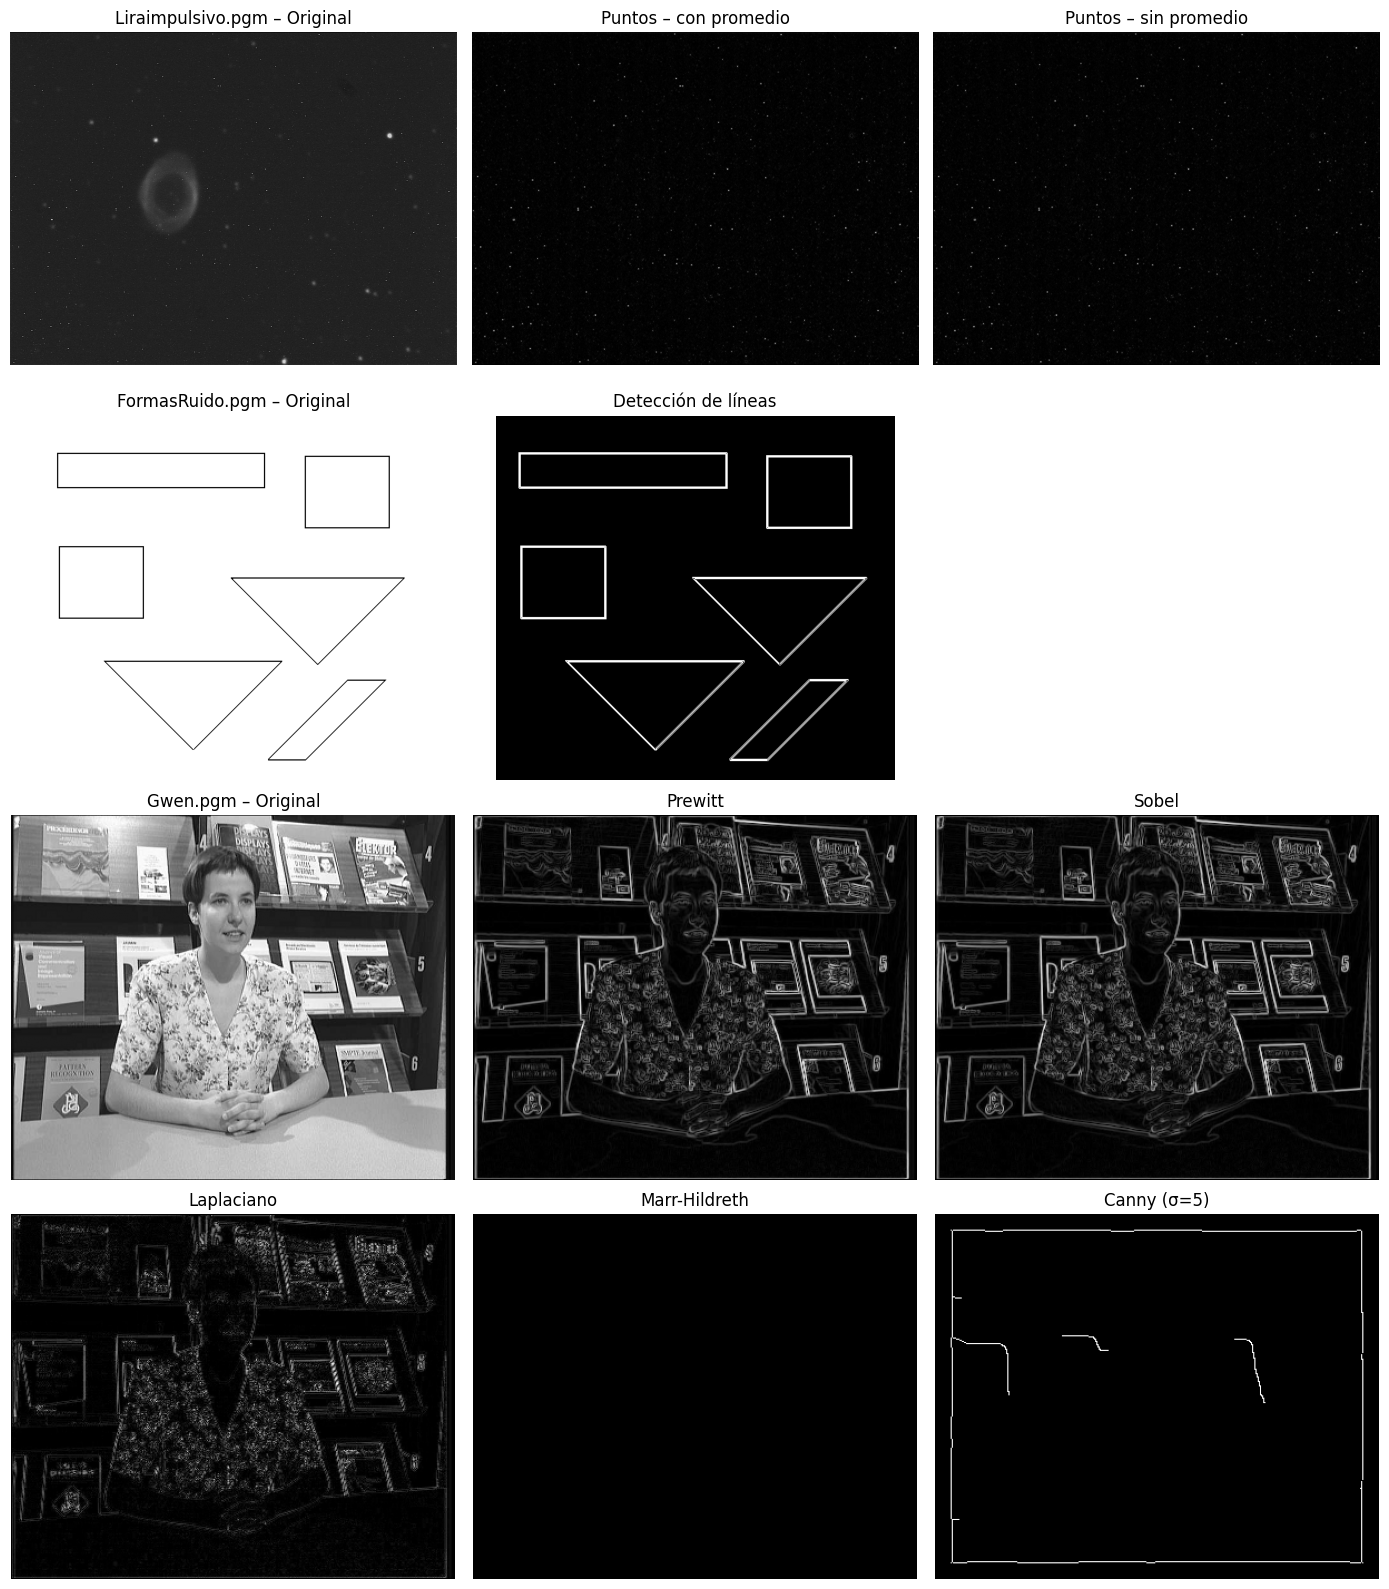

In [9]:
img1 = cargar_imagen("images/Liraimpulsivo.pgm")
img2 = cargar_imagen("images/FormasRuido.pgm")
img3 = cargar_imagen("images/Gwen.pgm")

# =============================
# Procesamiento para cada imagen
# =============================

# ---- 1. Liraimpulsivo.pgm — Detectar puntos ----
puntos_con = detectar_puntos(img1, incluir_promedio=True)
puntos_sin = detectar_puntos(img1, incluir_promedio=False)

# ---- 2. FormasRuido.pgm — Líneas ----
lineas = detectar_lineas(img2, umbral=80)

# ---- 3,4,5. Gwen.pgm — Prewitt, Sobel, Laplaciano ----
edge_prewitt = prewitt(img3)
edge_sobel = sobel(img3)
edge_lap = laplaciano(img3)

# ---- 6. Marr–Hildreth ----
edge_marr = marr_hildreth(img3, sigma=2)

# ---- 7. Canny ----
edge_canny = canny(img3, sigma=5, t1=50, t2=120)

# =============================
# Construir GRID FINAL
# =============================

fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.ravel()

imagenes = [
    # --- Liraimpulsivo ---
    (img1, "Liraimpulsivo.pgm – Original"),
    (puntos_con, "Puntos – con promedio"),
    (puntos_sin, "Puntos – sin promedio"),

    # --- FormasRuido ---
    (img2, "FormasRuido.pgm – Original"),
    (lineas, "Detección de líneas"),
    (None, ""),  # espacio vacío (para completar el grid)

    # --- Gwen ---
    (img3, "Gwen.pgm – Original"),
    (edge_prewitt, "Prewitt"),
    (edge_sobel, "Sobel"),
    (edge_lap, "Laplaciano"),
    (edge_marr, "Marr-Hildreth"),
    (edge_canny, "Canny (σ=5)"),
]

# Mostrar cada imagen en su celda correspondiente
for ax, item in zip(axes, imagenes):
    img, title = item

    if img is None:  # espacio vacío
        ax.axis("off")
        continue

    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()